# Pruning test different models

## IMDB

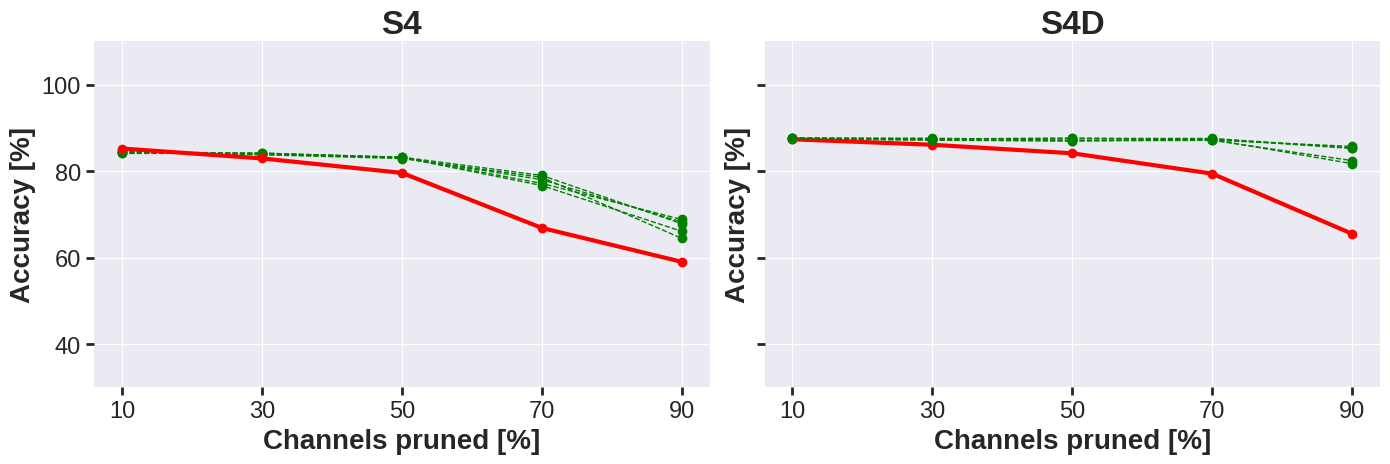

In [7]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [84.380, 83.772, 82.900, 78.552, 64.452],
        "2": [84.592, 84.020, 83.216, 78.992, 67.824],
        "3": [84.100, 84.144, 83.192, 77.148, 68.796],
        "4": [84.068, 84.156, 83.060, 78.020, 68.220],
        "5": [84.388, 83.852, 83.152, 76.656, 66.076],
        "Random": [85.21, 82.92, 79.58, 66.85, 59.01],
        #"Last_channels": [85.89, 85.92, 86.00, 84.83, 69.50]
    },
    "S4D": {
        "Random": [87.35, 86.08, 84.11, 79.4, 65.5],
        "1": [87.392, 87.240, 86.956, 87.444, 85.232],
        "2": [87.632, 87.424, 87.556, 87.536, 85.364],
        "3": [87.588, 87.600, 87.148, 87.140, 85.700],
        "4": [87.640, 87.444, 87.596, 87.296, 81.720],
        "5": [87.560, 87.120, 86.992, 87.104, 82.420],
        #"Last_channels": [87.72, 87.73, 87.74, 87.28, 81.89]
    }
} 

""" perc_reduction = {
    "S4D": {
        "time": {
            "Random": [1.09, 12.19, 23.29, 35.18, 48.35],
            "Exponential": [1.94, 13.48, 24.85, 36.98, 46.54],
            "Last_channels": [4.44, 14.51, 25.23, 36.98, 46.54]
        },
        "params": {
            "Random": [2.01, 6.02, 10.05, 14.06, 18.08],
            "Exponential": [2.0, 6.03, 10.05, 14.06, 18.09],
            "Last_channels": [2.0, 6.03, 10.05, 14.08, 18.09]
        }
    },
    "S4": {
        "time": {
            "Random": [5.0, 18.22, 30.94, 44.31, 59.6],
            "Exponential": [5.39, 18.44, 31.34, 45.51, 56.97],
            "Last_channels": [5.79, 18.58, 32.54, 44.91, 56.88]
        },
        "params": {
            "Random": [3.42, 9.99, 16.66, 23.29, 29.96],
            "Exponential": [3.32, 9.99, 16.66, 23.29, 29.96],
            "Last_channels": [3.32, 9.99, 16.66, 23.32, 29.96]
        }
    }
} """

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Random": 63,
    "Exponential": 61.5,
    #"Last_channels": 60
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color="red" if pattern_name == "Random" else "green", linestyle='-' if pattern_name == "Random" else '--', linewidth=3 if pattern_name == "Random" else 1)
        #ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=fc, linewidth=3 if pattern_name == "Random" else 1)
        """ ax.annotate(
            f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
            (x, offset_y),
            textcoords="offset points",
            xytext=(0, 0),
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
        ) """
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    #ax.legend(fontsize=20)
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=17,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("IMDB", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Listops

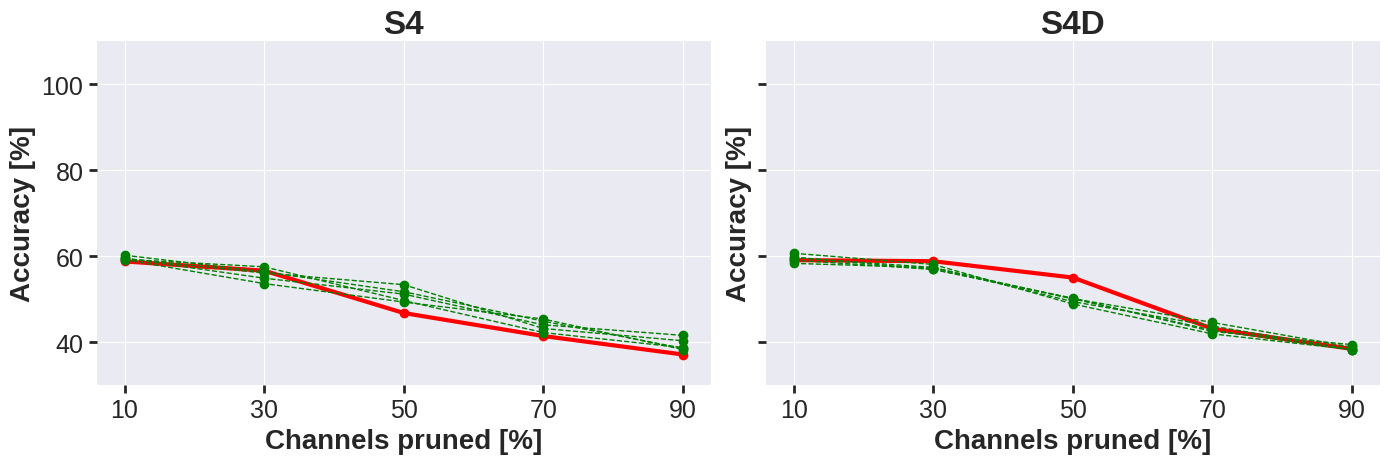

In [8]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "Random": [58.80, 56.65, 46.80, 41.45, 37.15],
        "1": [59.200, 53.650, 49.350, 45.400, 38.300],
        "2": [60.250, 56.400, 51.750, 44.900, 38.600], 
        "3": [59.500, 56.100, 53.400, 43.200, 40.350],
        "4": [59.550, 54.900, 51.200, 44.050, 41.600],
        "5": [59.300, 57.550, 49.700, 42.250, 38.750],
        #"Last_channels": [59.90, 56.20, 51.00, 41.95, 37.55]
    },
    "S4D": {
        "Random": [59.100, 58.850, 55.050, 43.150, 38.450],
        "1": [59.100, 56.950, 50.150, 44.600, 38.850],
        "2": [60.700, 58.100, 48.900, 41.950, 38.300],
        "3": [59.700, 57.400, 49.450, 43.750, 38.300],
        "4": [58.350, 57.350, 50.100, 42.800, 38.250],
        "5": [59.800, 56.950, 50.250, 42.500, 39.450],
        #"Last_channels": [59.85, 57.15, 48.00, 43.85, 38.15]
    }
}


""" perc_reduction = {
    "S4D": {
        "time": {
            "Random": [4.22, 18.15, 32.28, 46.81, 63.23],
            "Exponential": [4.59, 18.74, 32.91, 47.62, 61.35],
            "Last_channels": [6.64, 19.96, 33.45, 47.17, 60.45]
        },
        "params": {
            "Random": [3.29, 9.9, 16.52, 23.1, 29.71],
            "Exponential": [3.29, 9.9, 16.52, 23.1, 29.71],
            "Last_channels": [3.42, 9.90, 16.52, 23.13, 29.71]
        }
    },
    "S4": {
        "time": {
            "Random": [6.47, 20.67, 34.66, 49.0, 66.08],
            "Exponential": [6.67, 21.34, 35.16, 49.80, 63.30],
            "Last_channels": [6.67, 20.92, 34.66, 48.62, 54.43]
        },
        "params": {
            "Random": [4.89, 14.78, 24.68, 34.51, 44.41],
            "Exponential": [4.88, 14.78, 24.68, 34.58, 44.41],
            "Last_channels": [4.95, 14.78, 24.68, 34.51, 44.41]
        }
    }
} """

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Random": 40,
    "Exponential": 38.5,
    "Last_channels": 37
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color="red" if pattern_name == "Random" else "green", linestyle='-' if pattern_name == "Random" else '--', linewidth=3 if pattern_name == "Random" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    #ax.legend( fontsize=20)
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("listops", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Pathfinder

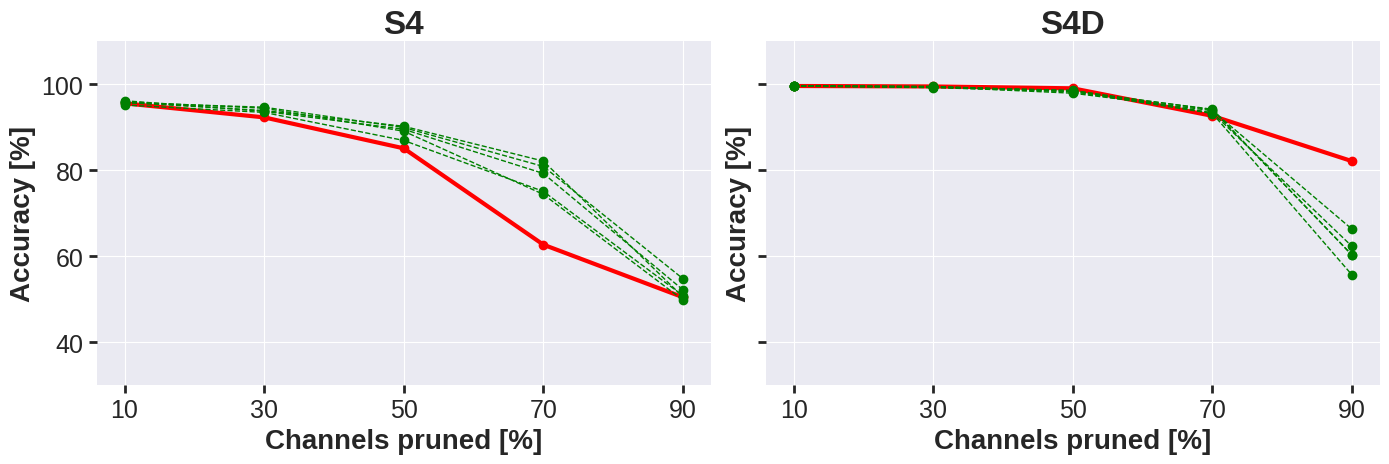

In [9]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "Random": [95.58, 92.31, 85.11, 62.7, 50.47],
        "1": [95.185, 93.470, 86.944, 75.094, 50.848],
        "2": [96.185, 93.720, 89.539, 79.269, 52.198],
        "3": [95.775, 93.905, 90.240, 82.144, 50.558],
        "4": [95.715, 94.675, 89.954, 80.899, 54.783],
        "5": [95.930, 94.445, 89.094, 74.404, 49.822],
        #"Last_channels": [96.29, 94.60, 88.60, 62.16, 50.31]
    },
    "S4D": {
        "Random": [99.61, 99.51, 99.07, 92.66, 82.12],
        "1": [99.720, 99.415, 98.520, 94.075, 60.283],
        "2": [99.600, 99.360, 98.595, 93.385, 62.293],
        "3": [99.605, 99.415, 97.935, 93.870, 66.293],
        "4": [99.590, 99.230, 98.300, 93.210, 55.638],
        "5": [99.670, 99.530, 98.280, 94.205, 60.238],
        #"Last_channels": [99.53, 99.26, 96.20, 89.97, 68.61]
    }
}

""" perc_reduction = {
    "S4D": {
        "time": {
            "Random": [2.69, 15.23, 28.57, 43.46, 48.85],
            "Exponential": [3.07, 14.62, 26.15, 38.08, 45.19],
            "Last_channels": [5.77, 15.77, 23.85, 34.23, 44.62]
        },
        "params": {
            "Random": [2.01, 6.02, 10.04, 14.06, 18.08],
            "Exponential": [2.0, 6.02, 10.05, 14.06, 18.07],
            "Last_channels": [2.0, 6.02, 10.05, 14.06, 18.08]
        }
    },
    "S4": {
        "time": {
            "Random": [5.37, 16.53, 28.1, 40.49, 50.52],
            "Exponential": [5.17, 16.32, 26.7, 38.84, 46.9],
            "Last_channels": [5.37, 16.32, 24.59, 35.95, 46.57]
        },
        "params": {
            "Random": [3.31, 9.97, 16.64, 23.30, 29.95],
            "Exponential": [3.32, 9.97, 16.65, 23.30, 29.95],
            "Last_channels": [3.32, 9.97, 16.65, 23.30, 29.95]
        }
    }
} """

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Random": 58,
    "Exponential": 55.5,
    "Last_channels": 53
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
       ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color="red" if pattern_name == "Random" else "green", linestyle='-' if pattern_name == "Random" else '--', linewidth=3 if pattern_name == "Random" else 1)
        
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    #ax.legend(fontsize=20)
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)
    
#fig.suptitle("pathfinder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## ECG

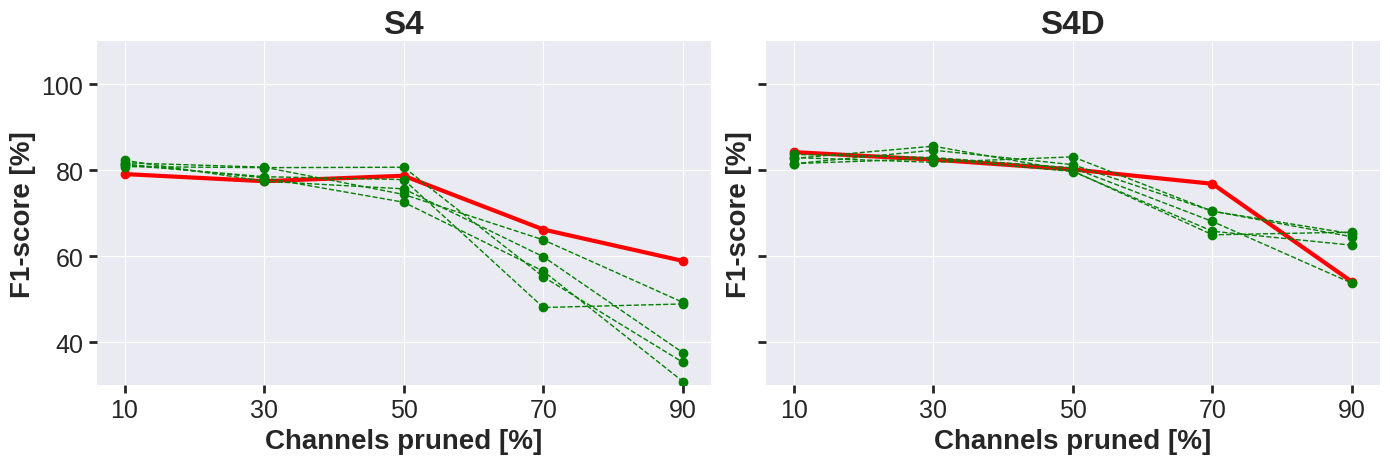

In [1]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "Random": [79.125, 77.464, 78.733, 66.229, 58.918],
        "1": [81.736, 80.731, 74.378, 63.816, 49.275],
        "2": [81.472, 78.251, 72.577, 56.539, 30.866],
        "3": [80.852, 80.622, 80.713, 55.210, 35.321],
        "4": [81.237, 78.514, 77.833, 48.086, 48.912],
        "5": [82.294, 77.464, 75.681, 59.895, 37.553],
        #"Last_channels": [96.29, 94.60, 88.60, 62.16, 50.31]
    },
    "S4D": {
        "Random": [84.233, 82.487, 80.203, 76.864, 54.043],
        "1": [82.769, 85.607, 79.844, 64.993, 65.615],
        "2": [83.705, 82.972, 80.557, 68.097, 53.728],
        "3": [82.951, 81.862, 83.126, 70.488, 65.238],
        "4": [81.529, 84.675, 81.308, 70.496, 64.528],
        "5": [81.549, 82.714, 79.720, 65.825, 62.579],
        #"Last_channels": [99.53, 99.26, 96.20, 89.97, 68.61]
    }
}

""" perc_reduction = {
    "S4D": {
        "time": {
            "Random": [2.69, 15.23, 28.57, 43.46, 48.85],
            "Exponential": [3.07, 14.62, 26.15, 38.08, 45.19],
            "Last_channels": [5.77, 15.77, 23.85, 34.23, 44.62]
        },
        "params": {
            "Random": [2.01, 6.02, 10.04, 14.06, 18.08],
            "Exponential": [2.0, 6.02, 10.05, 14.06, 18.07],
            "Last_channels": [2.0, 6.02, 10.05, 14.06, 18.08]
        }
    },
    "S4": {
        "time": {
            "Random": [5.37, 16.53, 28.1, 40.49, 50.52],
            "Exponential": [5.17, 16.32, 26.7, 38.84, 46.9],
            "Last_channels": [5.37, 16.32, 24.59, 35.95, 46.57]
        },
        "params": {
            "Random": [3.31, 9.97, 16.64, 23.30, 29.95],
            "Exponential": [3.32, 9.97, 16.65, 23.30, 29.95],
            "Last_channels": [3.32, 9.97, 16.65, 23.30, 29.95]
        }
    }
} """

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Random": 58,
    "Exponential": 55.5,
    "Last_channels": 53
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color="red" if pattern_name == "Random" else "green", linestyle='-' if pattern_name == "Random" else '--', linewidth=3 if pattern_name == "Random" else 1)
        
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("F1-score [%]", fontsize=20, fontweight='bold')
    #ax.legend(fontsize=20)
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)
    
#fig.suptitle("pathfinder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

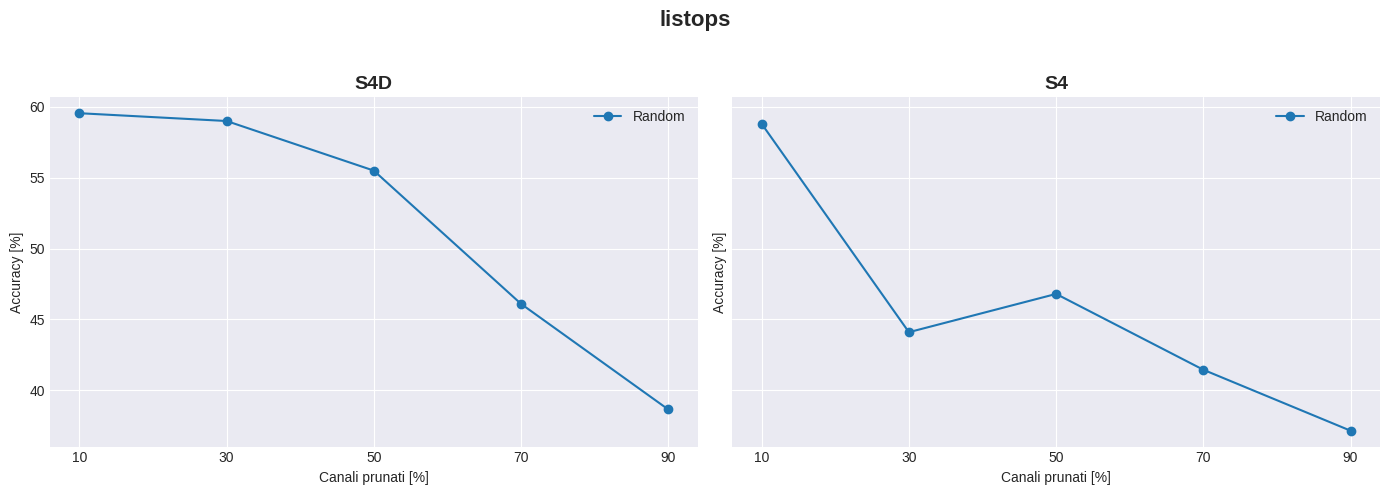

# Pruning test exponential same model

## IMDB


In [ ]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4D": {
        "Exponential": [86.672, 86.840, 86.844, 86.640, 80.916]
    },
    "S4": {
        "Exponential": [85.89, 85.956, 85.768, 84.552, 76.836]
    },
} 

perc_reduction = {
    "S4D": {
        "time": {
            "Exponential": [2.64, 14.26, 25.78, 37.21, 47.65]
        },
        "params": {
            "Exponential": [1.96, 5.98, 10.02, 14.08, 18.1]
        }
    },
    "S4": {
        "time": {
            "Exponential": [5.51, 17.31, 28.96, 40.45, 51.48]
        },
        "params": {
            "Exponential": [3.25, 9.91, 16.59, 23.32, 29.98]
        }
    }
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Exponential": 78,
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name)
        offset_y = offsets.get(pattern_name, 0)
        for i, (x, y) in enumerate(zip(pruning_perc, acc_values)):
            fc = "lightblue"
            ax.annotate(
                f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
                (x, offset_y),
                textcoords="offset points",
                xytext=(0, 0),
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
            )
    
    ax.set_title(f"{model_name} (86.000)" if model_name == "S4" else f"{model_name} (86.388)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Riquadri colorati: Accuratezza - Tempo - Parametri")
    ax.grid(True)

fig.suptitle("IMDB", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Listops


In [ ]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4D": {
        "Exponential": [60.200, 60.250, 56.550, 45.300, 37.950]
    },
    "S4": {
        "Exponential": [58.300, 56.500, 52.650, 45.100, 39.300]
    },
} 

perc_reduction = {
    "S4D": {
        "time": {
            "Exponential": [5.0, 19.40, 33.63, 47.67, 60.84]
        },
        "params": {
            "Exponential": [1.95, 5.94, 9.95, 13.98, 17.97]
        }
    },
    "S4": {
        "time": {
            "Exponential": [7.02, 21.75, 36.34, 50.63, 64.56]
        },
        "params": {
            "Exponential": [3.24, 9.86, 16.5, 23.19, 29.81]
        }
    }
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Exponential": 40,
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name)
        offset_y = offsets.get(pattern_name, 0)
        for i, (x, y) in enumerate(zip(pruning_perc, acc_values)):
            fc = "lightblue"
            ax.annotate(
                f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
                (x, offset_y),
                textcoords="offset points",
                xytext=(0, 0),
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
            )
    
    ax.set_title(f"{model_name} (58.300)" if model_name == "S4" else f"{model_name} (60.350)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Riquadri colorati: Accuratezza - Tempo - Parametri")
    ax.grid(True)

fig.suptitle("Listops", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Pathfinder

In [ ]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4D": {
        "Exponential": [99.340, 99.270, 98.255, 95.080, 69.553]
    },
    "S4": {
        "Exponential": [99.180, 98.765, 97.605, 95.170, 83.614]
    },
} 

perc_reduction = {
    "S4D": {
        "time": {
            "Exponential": [3.83, 14.94, 26.44, 37.55, 45.21]
        },
        "params": {
            "Exponential": [1.96, 5.98, 10.01, 14.06, 18.08]
        }
    },
    "S4": {
        "time": {
            "Exponential": [5.6, 17.4, 29.2, 40.29, 48.38]
        },
        "params": {
            "Exponential": [3.25, 9.9, 16.58, 23.30, 29.95]
        }
    }
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Exponential": 75,
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name)
        offset_y = offsets.get(pattern_name, 0)
        for i, (x, y) in enumerate(zip(pruning_perc, acc_values)):
            fc = "lightblue"
            ax.annotate(
                f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
                (x, offset_y),
                textcoords="offset points",
                xytext=(0, 0),
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
            )
    
    ax.set_title(f"{model_name} (97.065)" if model_name == "S4" else f"{model_name} (97.675)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Riquadri colorati: Accuratezza - Tempo - Parametri")
    ax.grid(True)

fig.suptitle("Pathfinder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Pruning test with some % pruned iterative

## Listops

In [ ]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4D": {
        "Exponential": [60.200, 60.250, 56.550, 45.300, 37.950],
        "Exponential2": [60.200, 60.250, 57.850, 49.100, 37.950]
    },
    "S4": {
        "Exponential": [58.300, 56.500, 52.650, 45.100, 39.300],
        "Exponential2": [58.300, 56.500, 51.200, 46.000, 40.450]
    },
} 

perc_reduction = {
    "S4D": {
        "time": {
            "Exponential": [5.0, 19.40, 33.63, 47.67, 60.84],
            "Exponential2": [5.0, 19.40, 33.36, 47.5, 60.84]
        },
        "params": {
            "Exponential": [1.95, 5.94, 9.95, 13.98, 17.97],
            "Exponential2": [1.95, 5.94, 9.87, 13.98, 17.97]
        }
    },
    "S4": {
        "time": {
            "Exponential": [7.02, 21.75, 36.34, 50.63, 64.56],
            "Exponential2": [7.02, 21.75, 36.07, 50.38, 64.49]
        },
        "params": {
            "Exponential": [3.24, 9.86, 16.5, 23.19, 29.81],
            "Exponential2": [3.24, 9.86, 16.37, 23.10, 29.7]
        }
    }
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Exponential": 40,
    "Exponential2": 42
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name)
        offset_y = offsets.get(pattern_name, 0)
        for i, (x, y) in enumerate(zip(pruning_perc, acc_values)):
            fc = "lightblue" if pattern_name == "Exponential" else "orange"
            ax.annotate(
                f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
                (x, offset_y),
                textcoords="offset points",
                xytext=(0, 0),
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
            )
    
    ax.set_title(f"{model_name} (58.300)" if model_name == "S4" else f"{model_name} (60.350)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]")
    ax.legend(title="Riquadri colorati: Accuratezza - Tempo - Parametri")
    ax.grid(True)

fig.suptitle("Listops", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Pruning dataset ECG

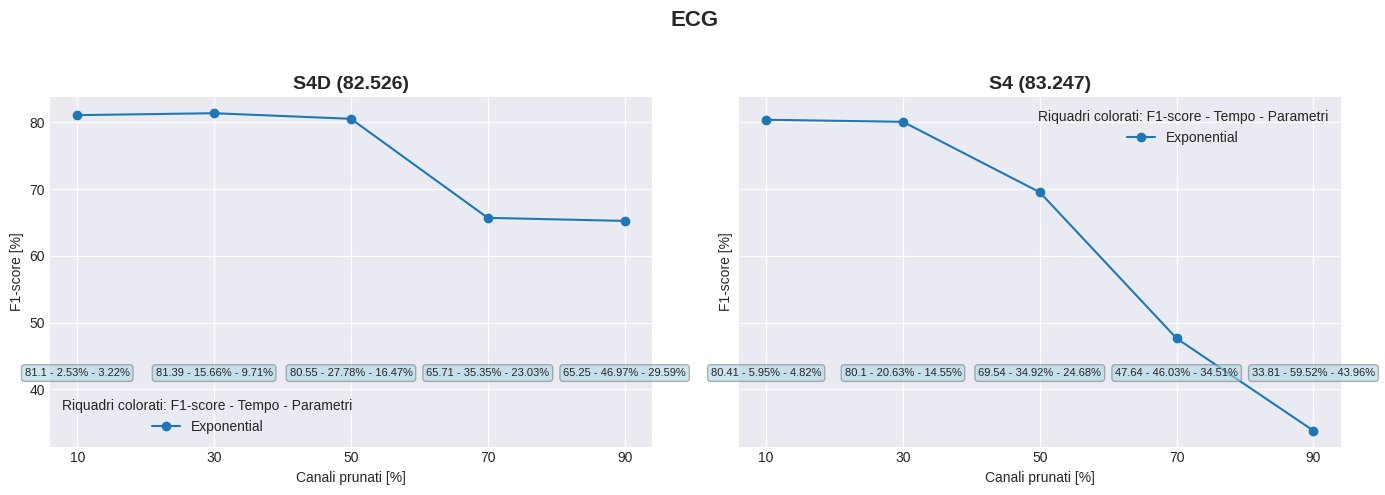

In [27]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4D": {
        "Exponential": [81.10, 81.39, 80.55, 65.71, 65.25]
    },
    "S4": {
        "Exponential": [80.41, 80.10, 69.54, 47.64, 33.81]
    },
} 

perc_reduction = {
    "S4D": {
        "time": {
            "Exponential": [2.53, 15.66, 27.78, 35.35, 46.97]
        },
        "params": {
            "Exponential": [3.22, 9.71, 16.47, 23.03, 29.59]
        }
    },
    "S4": {
        "time": {
            "Exponential": [5.95, 20.63, 34.92, 46.03, 59.52]
        },
        "params": {
            "Exponential": [4.82, 14.55, 24.68, 34.51, 43.96]
        }
    }
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

offsets = {
    "Exponential": 42,
}

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name)
        offset_y = offsets.get(pattern_name, 0)
        for i, (x, y) in enumerate(zip(pruning_perc, acc_values)):
            fc = "lightblue"
            ax.annotate(
                f"{y} - {perc_reduction[model_name]['time'][pattern_name][i]}% - {perc_reduction[model_name]['params'][pattern_name][i]}%", 
                (x, offset_y),
                textcoords="offset points",
                xytext=(0, 0),
                ha='center',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc=fc, alpha=0.6, ec="gray"),
            )
    
    ax.set_title(f"{model_name} (83.247)" if model_name == "S4" else f"{model_name} (82.526)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("F1-score [%]")
    ax.legend(title="Riquadri colorati: F1-score - Tempo - Parametri")
    ax.grid(True)

fig.suptitle("ECG", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Pruning con % incrementale (i canali prunati in uno step vengono riusati negli step successivi)

Qua vengono visualizzati 2 tipi di grafici:
- Quelli colorati che rappresentano modelli prunati (seed diversi), con canali prunati incrementali (riparto sempre dai canali prunati allo step precedente) ma ripartendo sempre dal modello base di partenza
- Quelli bianchi e neri che invece rappresentano modelli prunati, sempre in maniera incrementale (i canali) però ripartendo dai parametri del miglior modello ottenuto dallo step precedente (si testano 5 seed per ogni step e si tiene il migliore)

## IMDB (vecchio)

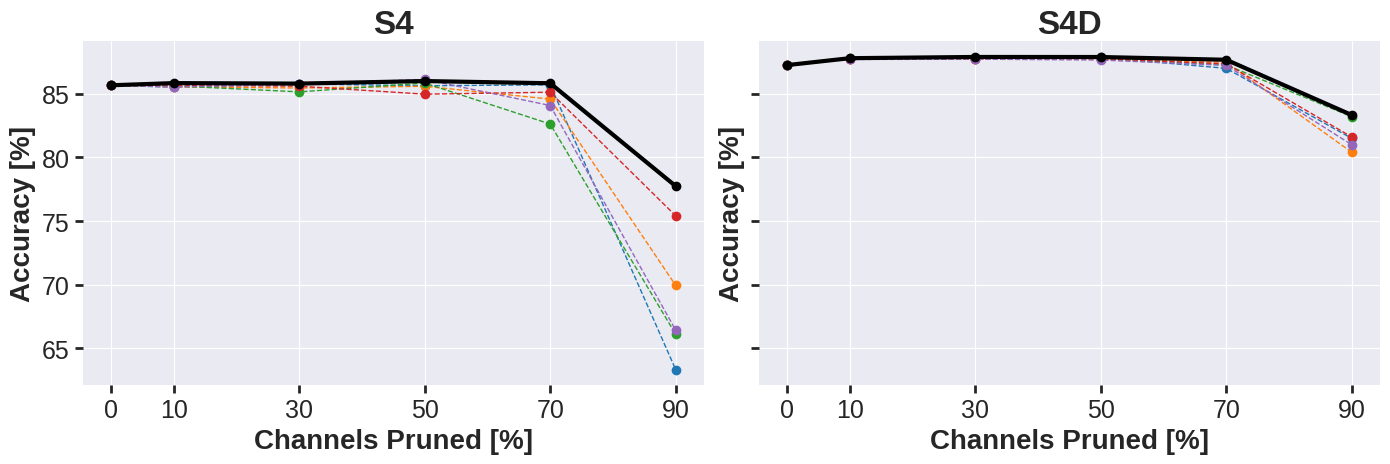

In [14]:
import matplotlib.pyplot as plt

pruning_perc = [0, 10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [85.668, 85.516, 85.772, 85.632, 85.704, 63.340],
        "2": [85.668, 85.548, 85.456, 85.592, 84.584, 69.952],
        "3": [85.668, 85.624, 85.152, 85.844, 82.624, 66.112],
        "4": [85.668, 85.680, 85.596, 84.972, 85.124, 75.420],
        "5": [85.668, 85.540, 85.764, 86.128, 84.080, 66.436],
        "6": [85.668, 85.840, 85.800, 86.000, 85.828, 77.748]
    },
    "S4D": {
        "1": [87.252, 87.740, 87.744, 87.868, 86.996, 81.496],
        "2": [87.252, 87.748, 87.736, 87.716, 87.468, 80.408],
        "3": [87.252, 87.780, 87.772, 87.776, 87.264, 83.200],
        "4": [87.252, 87.760, 87.712, 87.756, 87.352, 81.608],
        "5": [87.252, 87.696, 87.720, 87.652, 87.228, 81.000],
        "6": [87.252, 87.796, 87.892, 87.888, 87.672, 83.332]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "6":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name == "6" else None, linestyle='--' if pattern_name != "6" else '-', linewidth=3 if pattern_name == "6" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels Pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("IMDb", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## IMDB 

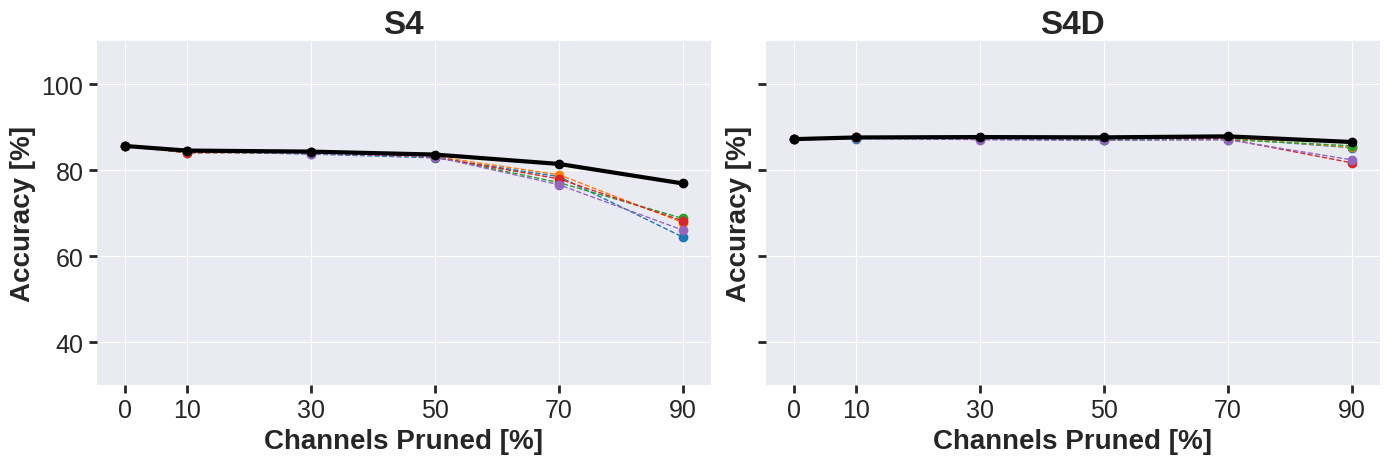

In [7]:
import matplotlib.pyplot as plt

pruning_perc = [0, 10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [85.668, 84.380, 83.772, 82.900, 78.552, 64.452],
        "2": [85.668, 84.592, 84.020, 83.216, 78.992, 67.824],
        "3": [85.668, 84.100, 84.144, 83.192, 77.148, 68.796],
        "4": [85.668, 84.068, 84.156, 83.060, 78.020, 68.220],
        "5": [85.668, 84.388, 83.852, 83.152, 76.656, 66.076],
        "6": [85.668, 84.592, 84.352, 83.664, 81.484, 76.932]
    },
    "S4D": {
        "1": [87.252, 87.392, 87.240, 86.956, 87.444, 85.232],
        "2": [87.252, 87.632, 87.424, 87.556, 87.536, 85.364],
        "3": [87.252, 87.588, 87.600, 87.148, 87.140, 85.700],
        "4": [87.252, 87.640, 87.444, 87.596, 87.296, 81.720],
        "5": [87.252, 87.560, 87.120, 86.992, 87.104, 82.420],
        "6": [87.252, 87.640, 87.728, 87.664, 87.896, 86.580]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "6":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name == "6" else None, linestyle='--' if pattern_name != "6" else '-', linewidth=3 if pattern_name == "6" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels Pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("IMDb", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Listops


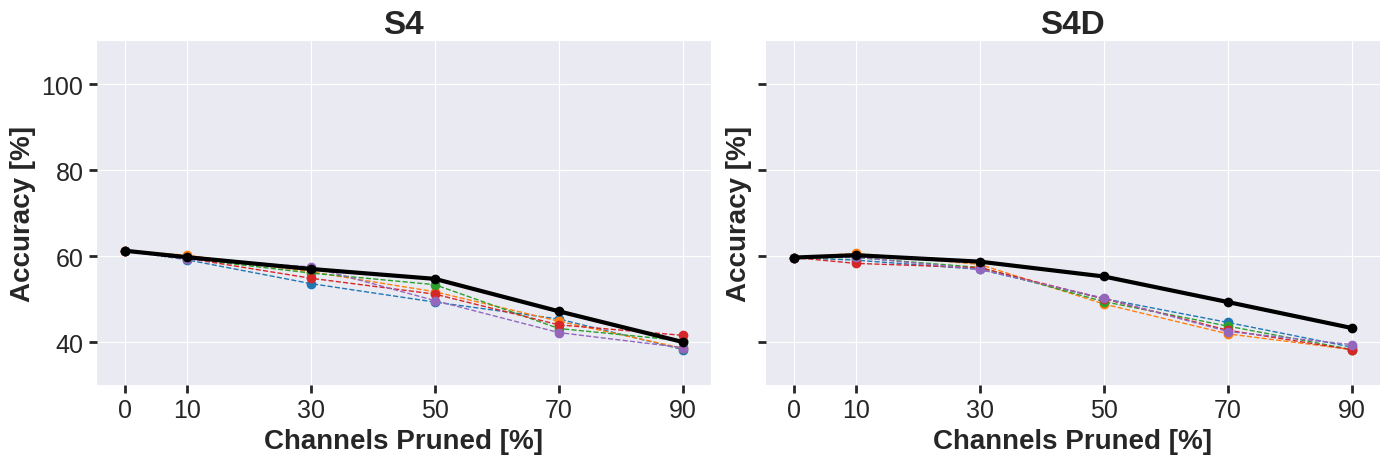

In [8]:
import matplotlib.pyplot as plt

pruning_perc = [0, 10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [61.300, 59.200, 53.650, 49.350, 45.400, 38.300],
        "2": [61.300, 60.250, 56.400, 51.750, 44.900, 38.600], 
        "3": [61.300, 59.500, 56.100, 53.400, 43.200, 40.350],
        "4": [61.300, 59.550, 54.900, 51.200, 44.050, 41.600],
        "5": [61.300, 59.300, 57.550, 49.700, 42.250, 38.750],
        "6": [61.300, 59.800, 57.050, 54.750, 47.200, 40.050]
    },
    "S4D": {
        "1": [59.700, 59.100, 56.950, 50.150, 44.600, 38.850],
        "2": [59.700, 60.700, 58.100, 48.900, 41.950, 38.300],
        "3": [59.700, 59.700, 57.400, 49.450, 43.750, 38.300],
        "4": [59.700, 58.350, 57.350, 50.100, 42.800, 38.250],
        "5": [59.700, 59.800, 56.950, 50.250, 42.500, 39.450],
        "6": [59.700, 60.250, 58.750, 55.300, 49.350, 43.300]
    }
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "6":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name == "6" else None, linestyle='--' if pattern_name != "6" else '-', linewidth=3 if pattern_name == "6" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels Pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("ListOps", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Pathfinder

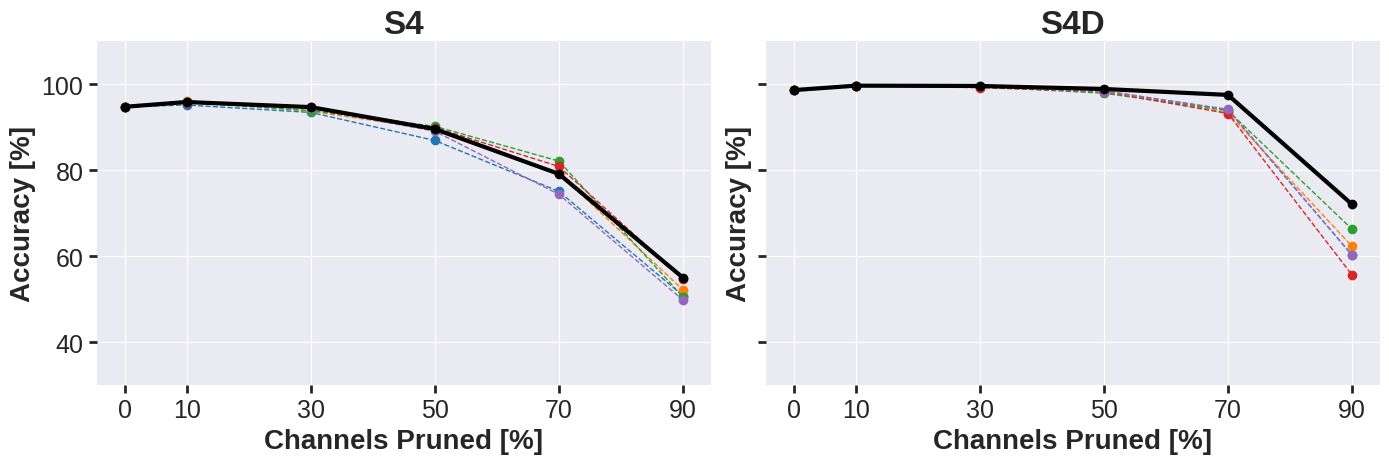

In [7]:
import matplotlib.pyplot as plt

pruning_perc = [0, 10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [94.770, 95.185, 93.470, 86.944, 75.094, 50.848],
        "2": [94.770, 96.185, 93.720, 89.539, 79.269, 52.198],
        "3": [94.770, 95.775, 93.905, 90.240, 82.144, 50.558],
        "4": [94.770, 95.715, 94.675, 89.954, 80.899, 54.783],
        "5": [94.770, 95.930, 94.445, 89.094, 74.404, 49.822],
        #"6": [95.885, 94.405, 88.184, 73.974, 52.108], 10 epoche
        "7": [94.770, 95.885, 94.700, 89.604, 79.159, 55.023]
    },
    "S4D": {
        "1": [98.655, 99.720, 99.415, 98.520, 94.075, 60.283],
        "2": [98.655, 99.600, 99.360, 98.595, 93.385, 62.293],
        "3": [98.655, 99.605, 99.415, 97.935, 93.870, 66.293],
        "4": [98.655, 99.590, 99.230, 98.300, 93.210, 55.638],
        "5": [98.655, 99.670, 99.530, 98.280, 94.205, 60.238],
        #"6": [99.665, 99.555, 98.860, 96.540, 71.359], 10 epoche
        "7": [98.655, 99.685, 99.620, 98.920, 97.535, 72.069]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "6":
            color = "white"
        elif pattern_name == "7":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name == "7" else None, linestyle='--' if pattern_name != "7" else '-', linewidth=3 if pattern_name == "7" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels Pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuracy [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("Pathfinder", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## ECG


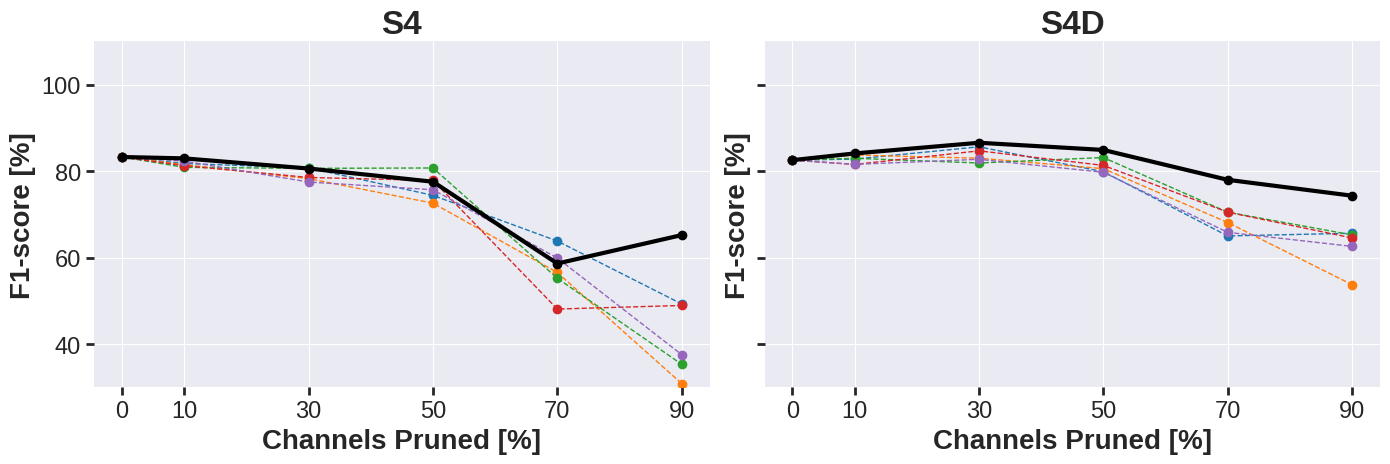

In [10]:
import matplotlib.pyplot as plt

pruning_perc = [0, 10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [83.247, 81.736, 80.731, 74.378, 63.816, 49.275],
        "2": [83.247, 81.472, 78.251, 72.577, 56.539, 30.866],
        "3": [83.247, 80.852, 80.622, 80.713, 55.210, 35.321],
        "4": [83.247, 81.237, 78.514, 77.833, 48.086, 48.912],
        "5": [83.247, 82.294, 77.464, 75.681, 59.895, 37.553],
        #"6": [84.392, 84.374, 78.226, 62.013, 56.863], 10 epoche
        "7": [83.247, 82.933, 80.585, 77.534, 58.616, 65.188]
    },
    "S4D": {
        "1": [82.526, 82.769, 85.607, 79.844, 64.993, 65.615],
        "2": [82.526, 83.705, 82.972, 80.557, 68.097, 53.728],
        "3": [82.526, 82.951, 81.862, 83.126, 70.488, 65.238],
        "4": [82.526, 81.529, 84.675, 81.308, 70.496, 64.528],
        "5": [82.526, 81.549, 82.714, 79.720, 65.825, 62.579],
        #"6": [83.847, 81.800, 80.869, 71.422, 69.977], 10 epoche
        "7": [82.526, 84.074, 86.543, 84.883, 77.974, 74.300]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "6":
            color = "white"
        elif pattern_name == "7":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name == "7" else None, linestyle='--' if pattern_name != "7" else '-', linewidth=3 if pattern_name == "7" else 1)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels Pruned [%]", fontsize=20, fontweight='bold')
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("F1-score [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(30, 110)
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=17,
        length=6,
        width=2
    )
    ax.grid(True)

#fig.suptitle("ECG", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Pruning con early stopping (confronto con i risultati prima)

## ECG

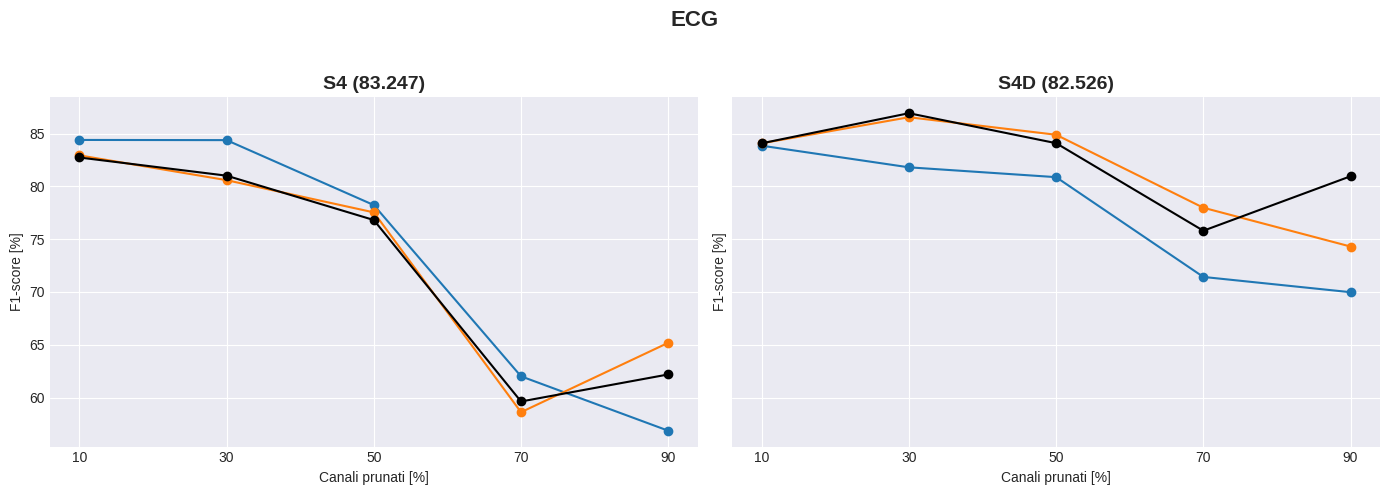

In [1]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [84.392, 84.374, 78.226, 62.013, 56.863], # 10 epoche
        "2": [82.933, 80.585, 77.534, 58.616, 65.188], # 20 epoche
        "3": [82.730, 81.010, 76.810, 59.630, 62.190]  # 20 epoche + early stopping
    },
    "S4D": {
        "1": [83.847, 81.800, 80.869, 71.422, 69.977], # 10 epoche
        "2": [84.074, 86.543, 84.883, 77.974, 74.300], # 20 epoche
        "3": [84.074, 86.923, 84.085, 75.796, 80.954]  # 20 epoche + early stopping
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name} (83.247)" if model_name == "S4" else f"{model_name} (82.526)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("F1-score [%]")
    ax.grid(True)

fig.suptitle("ECG", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Pathfinder

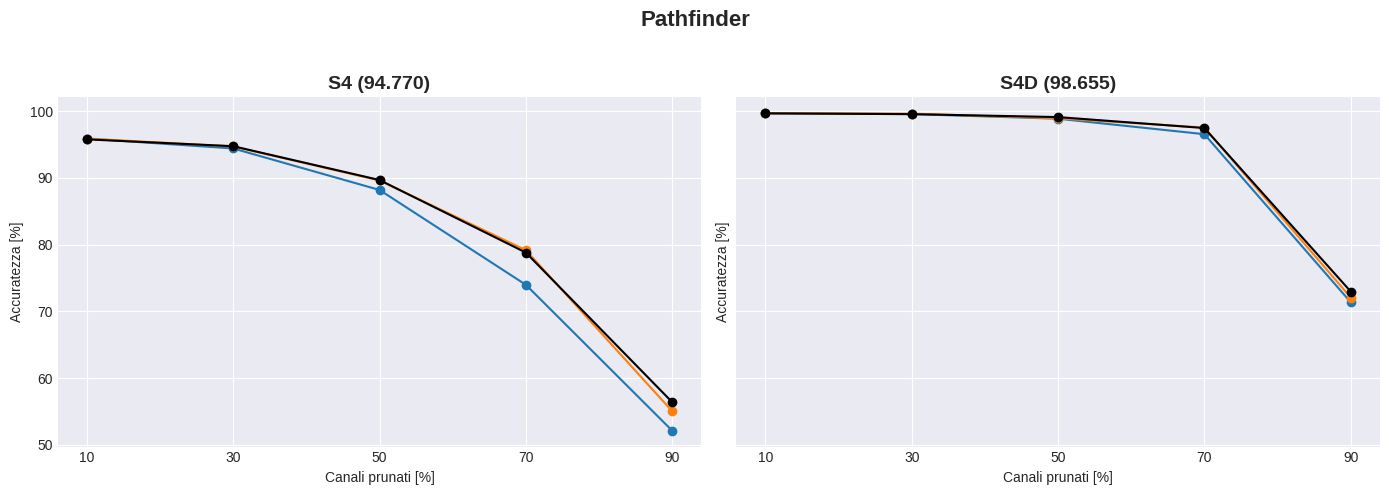

In [1]:
import matplotlib.pyplot as plt

pruning_perc = [10, 30, 50, 70, 90]

results = {
    "S4": {
        "1": [95.885, 94.405, 88.184, 73.974, 52.108], # 10 epoche
        "2": [95.885, 94.700, 89.604, 79.159, 55.023], # 20 epoche
        "3": [95.765, 94.740, 89.674, 78.799, 56.383]  # 20 epoche + early stopping 
    },
    "S4D": {
        "1": [99.665, 99.555, 98.860, 96.540, 71.359], # 10 epoche
        "2": [99.685, 99.620, 98.920, 97.535, 72.069], # 20 epoche
        "3": [99.665, 99.545, 99.105, 97.460, 72.964]  # 20 epoche + early stopping
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name} (94.770)" if model_name == "S4" else f"{model_name} (98.655)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Accuratezza [%]")
    ax.grid(True)

fig.suptitle("Pathfinder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## ListOps

Per ListOps i risultati sono gli stessi visto che le epoche vengoni fatte tutte quante

# Test latency ogni 5%

## IMDb

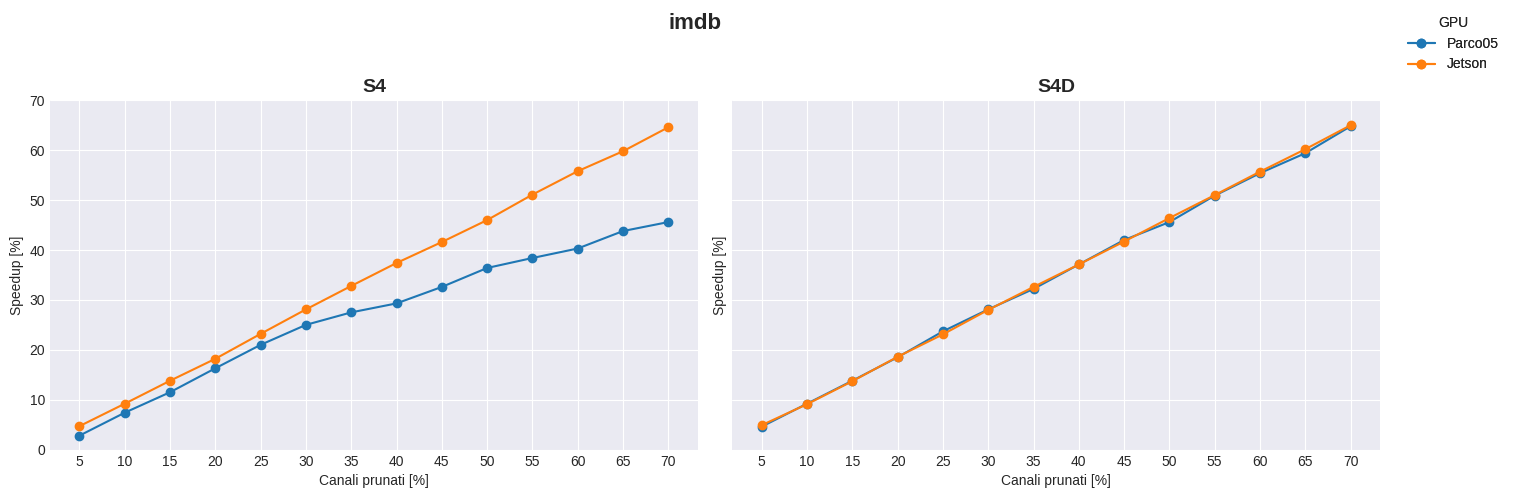

In [3]:
import matplotlib.pyplot as plt

pruning_perc = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "parco": [2.8, 7.4, 11.5, 16.3, 21.0, 25.0, 27.5, 29.3, 32.6, 36.4, 38.4, 40.3, 43.8, 45.6],
        "jetson": [4.7, 9.2, 13.8, 18.2, 23.2, 28.1, 32.8, 37.4, 41.6, 46.0, 51.1, 55.8, 59.8, 64.6]
    },
    "S4D": {
        "parco": [4.6, 9.2, 13.8, 18.5, 23.7, 28.1, 32.2, 37.1, 42.0, 45.6, 50.9, 55.4, 59.4, 64.8],
        "jetson": [4.9, 9.1, 13.7, 18.6, 23.1, 28.0, 32.6, 37.1, 41.7, 46.4, 51.0, 55.7, 60.2, 65.0]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Speedup [%]")
    ax.set_ylim(0, 70)
    ax.grid(True)
    fig.legend(["Parco05", "Jetson"], title="GPU", loc='upper left', bbox_to_anchor=(1, 1))

fig.suptitle("imdb", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Listops

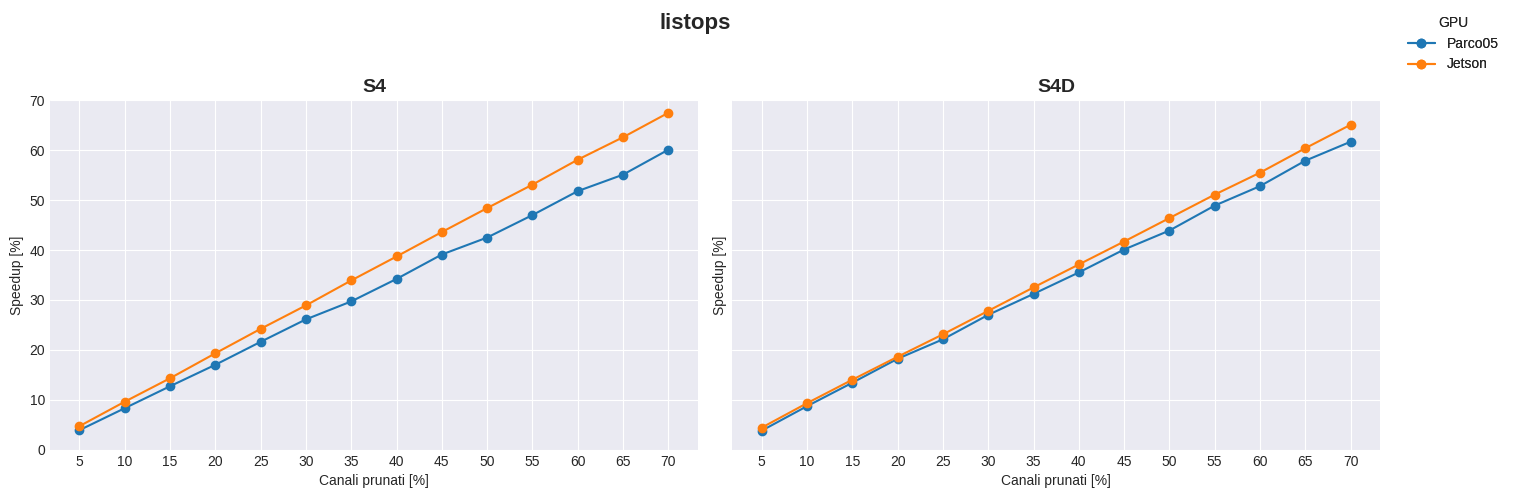

In [2]:
import matplotlib.pyplot as plt

pruning_perc = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "parco": [3.9, 8.3, 12.7, 17.0, 21.6, 26.1, 29.7, 34.2, 39.1, 42.5, 47.0, 51.8, 55.1, 60.1],
        "jetson": [4.7, 9.6, 14.3, 19.3, 24.2, 28.9, 33.9, 38.7, 43.6, 48.4, 53.1, 58.1, 62.6, 67.5]
    },
    "S4D": {
        "parco": [3.8, 8.7, 13.4, 18.2, 22.1, 27.0, 31.2, 35.5, 40.1, 43.9, 48.9, 52.8, 57.9, 61.7],
        "jetson": [4.4, 9.3, 14.0, 18.6, 23.1, 27.8, 32.5, 37.1, 41.7, 46.4, 51.1, 55.5, 60.4, 65.1]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Speedup [%]")
    ax.set_ylim(0, 70)
    ax.grid(True)
    fig.legend(["Parco05", "Jetson"], title="GPU", loc='upper left', bbox_to_anchor=(1, 1))

fig.suptitle("listops", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Pathfinder

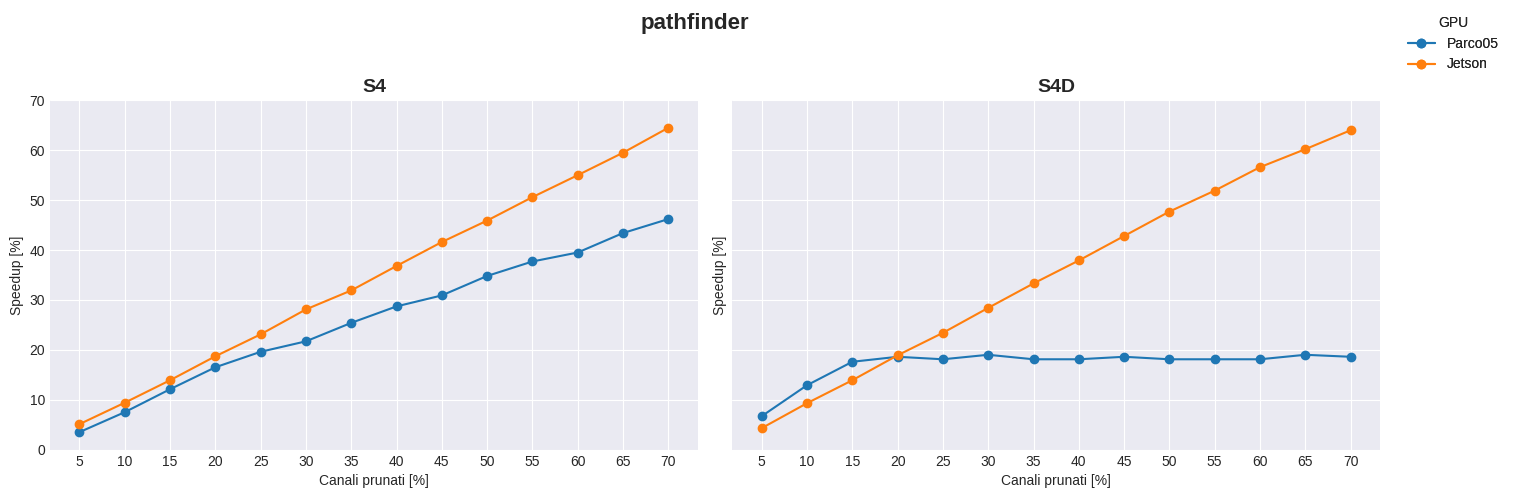

In [6]:
import matplotlib.pyplot as plt

pruning_perc = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "parco": [3.5, 7.5, 12.1, 16.5, 19.6, 21.7, 25.4, 28.7, 30.9, 34.8, 37.7, 39.5, 43.4, 46.2],
        "jetson": [5.1, 9.4, 13.9, 18.7, 23.1, 28.1, 31.9, 36.8, 41.6, 45.9, 50.6, 55.0, 59.5, 64.5]
    },
    "S4D": {
        "parco": [6.7, 12.9, 17.6, 18.6, 18.1, 19.0, 18.1, 18.1, 18.6, 18.1, 18.1, 18.1, 19.0, 18.6],
        "jetson": [4.3, 9.3, 13.9, 18.9, 23.4, 28.4, 33.3, 37.9, 42.8, 47.7, 51.9, 56.6, 60.2, 64.0]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Speedup [%]")
    ax.set_ylim(0, 70)
    ax.grid(True)
    fig.legend(["Parco05", "Jetson"], title="GPU", loc='upper left', bbox_to_anchor=(1, 1))

fig.suptitle("pathfinder", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## ECG

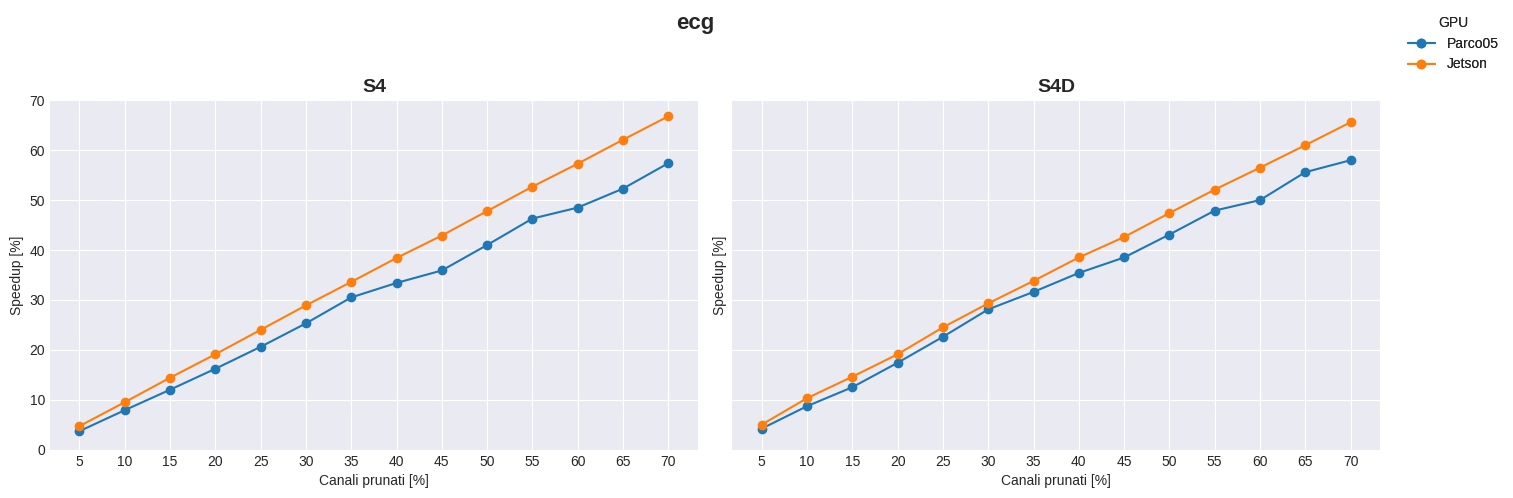

In [6]:
import matplotlib.pyplot as plt

pruning_perc = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "parco": [3.7, 7.9, 12.0, 16.2, 20.6, 25.3, 30.5, 33.4, 35.9, 41.0, 46.3, 48.5, 52.3, 57.4],
        "jetson": [4.7, 9.5, 14.4, 19.1, 24.0, 28.9, 33.6, 38.4, 42.9, 47.8, 52.7, 57.3, 62.1, 66.8]
    },
    "S4D": {
        "parco": [4.2, 8.7, 12.5, 17.4, 22.6, 28.1, 31.6, 35.4, 38.5, 43.1, 47.9, 50.0, 55.6, 58.0],
        "jetson": [5.0, 10.3, 14.6, 19.1, 24.5, 29.3, 33.8, 38.5, 42.6, 47.4, 52.1, 56.5, 61.0, 65.6]
    },
} 


plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Canali prunati [%]")
    ax.set_xticks(pruning_perc)
    ax.set_ylabel("Speedup [%]")
    ax.set_ylim(0, 70)
    ax.grid(True)
    fig.legend(["Parco05", "Jetson"], title="GPU", loc='upper left', bbox_to_anchor=(1, 1))

fig.suptitle("ecg", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Confronto GPU parco05

/tmp/ipykernel_1040536/994024889.py:109: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend(


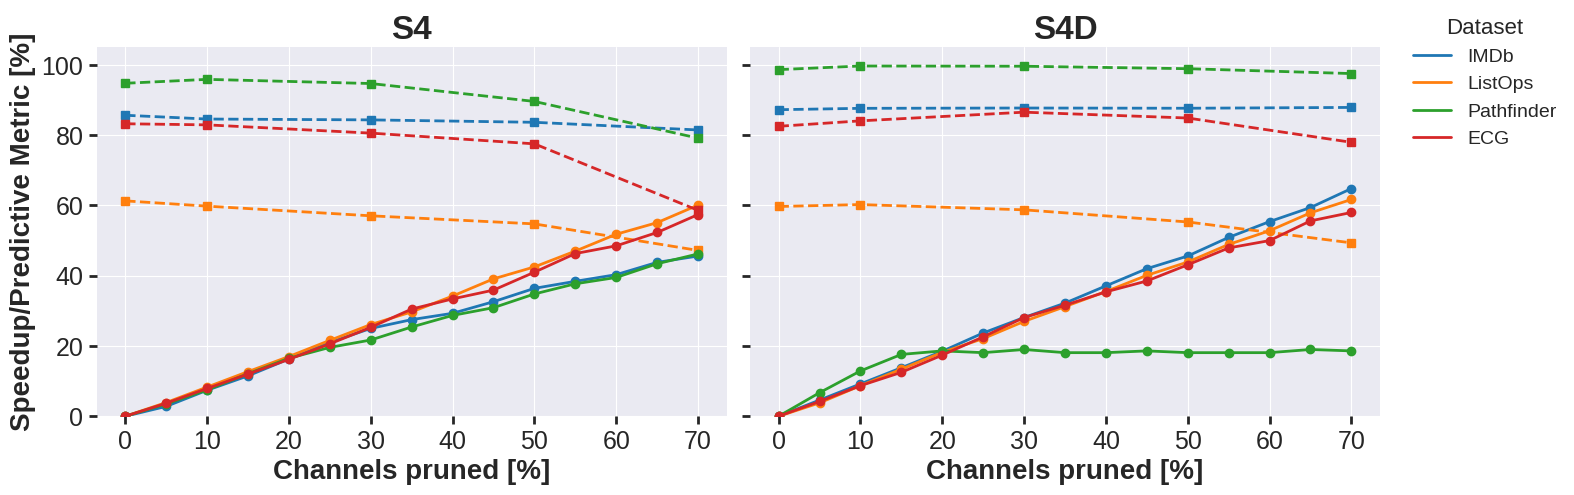

In [59]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pruning_perc = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "imdb": [0, 2.8, 7.4, 11.5, 16.3, 21.0, 25.0, 27.5, 29.3, 32.6, 36.4, 38.4, 40.3, 43.8, 45.6],
        "listops": [0, 3.9, 8.3, 12.7, 17.0, 21.6, 26.1, 29.7, 34.2, 39.1, 42.5, 47.0, 51.8, 55.1, 60.1],
        "pathfinder": [0, 3.5, 7.5, 12.1, 16.5, 19.6, 21.7, 25.4, 28.7, 30.9, 34.8, 37.7, 39.5, 43.4, 46.2],
        "ecg": [0, 3.7, 7.9, 12.0, 16.2, 20.6, 25.3, 30.5, 33.4, 35.9, 41.0, 46.3, 48.5, 52.3, 57.4]
    },
    "S4D": {
        "imdb": [0, 4.6, 9.2, 13.8, 18.5, 23.7, 28.1, 32.2, 37.1, 42.0, 45.6, 50.9, 55.4, 59.4, 64.8],
        "listops": [0, 3.8, 8.7, 13.4, 18.2, 22.1, 27.0, 31.2, 35.5, 40.1, 43.9, 48.9, 52.8, 57.9, 61.7],
        "pathfinder": [0, 6.7, 12.9, 17.6, 18.6, 18.1, 19.0, 18.1, 18.1, 18.6, 18.1, 18.1, 18.1, 19.0, 18.6],
        "ecg": [0, 4.2, 8.7, 12.5, 17.4, 22.6, 28.1, 31.6, 35.4, 38.5, 43.1, 47.9, 50.0, 55.6, 58.0]
    },
}

acc_values = {
    "S4": {
        "imdb": [85.668, 84.592, 84.352, 83.664, 81.484],
        "listops": [61.300, 59.800, 57.050, 54.750, 47.200],
        "pathfinder": [94.770, 95.885, 94.700, 89.604, 79.159],
        "ecg": [83.247, 82.933, 80.585, 77.534, 58.616]
    },
    "S4D": {
        "imdb": [87.252, 87.640, 87.728, 87.664, 87.896],
        "listops": [59.700, 60.250, 58.750, 55.300, 49.350],
        "pathfinder": [98.655, 99.685, 99.620, 98.920, 97.535],
        "ecg": [82.526, 84.074, 86.543, 84.883, 77.974]
    }
}

pruning_acc = [0, 10, 30, 50, 70]   # punti dove hai accuracy

plt.style.use('seaborn-v0_8-darkgrid')

# colori fissi per dataset
dataset_colors = {
    "imdb": "tab:blue",
    "listops": "tab:orange",
    "pathfinder": "tab:green",
    "ecg": "tab:red"
}

fig, axes = plt.subplots(1, len(results), figsize=(14,5))

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):

    for dataset, speed in model_data.items():

        color = dataset_colors[dataset]

        # SPEEDUP
        ax.plot(
            pruning_perc,
            speed,
            marker='o',
            linewidth=2,
            color=color,
            linestyle='-'
        )

        # ACCURACY
        acc = acc_values[model_name][dataset]

        ax.plot(
            pruning_acc,
            acc,
            marker='s',
            linestyle='--',
            linewidth=2,
            color=color
        )

    ax.set_title(model_name, fontsize=24, fontweight='bold')

    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')

    if model_name == "S4":
        ax.set_ylabel("Speedup/Predictive Metric [%]", fontsize=20, fontweight='bold')
    else:
        ax.tick_params(labelleft=False)

    ax.set_ylim(0,105)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )

    ax.grid(True)

legend_elements = [
    Line2D([0], [0], color=dataset_colors["imdb"], lw=2, label="IMDb"),
    Line2D([0], [0], color=dataset_colors["listops"], lw=2, label="ListOps"),
    Line2D([0], [0], color=dataset_colors["pathfinder"], lw=2, label="Pathfinder"),
    Line2D([0], [0], color=dataset_colors["ecg"], lw=2, label="ECG"),
]

fig.legend(
    ["IMDb", "ListOps", "Pathfinder", "ECG"],
    handles=legend_elements,
    title="Dataset",
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=14,
    title_fontsize=16
)

fig.tight_layout()
plt.show()

## Confronto GPU Jetson

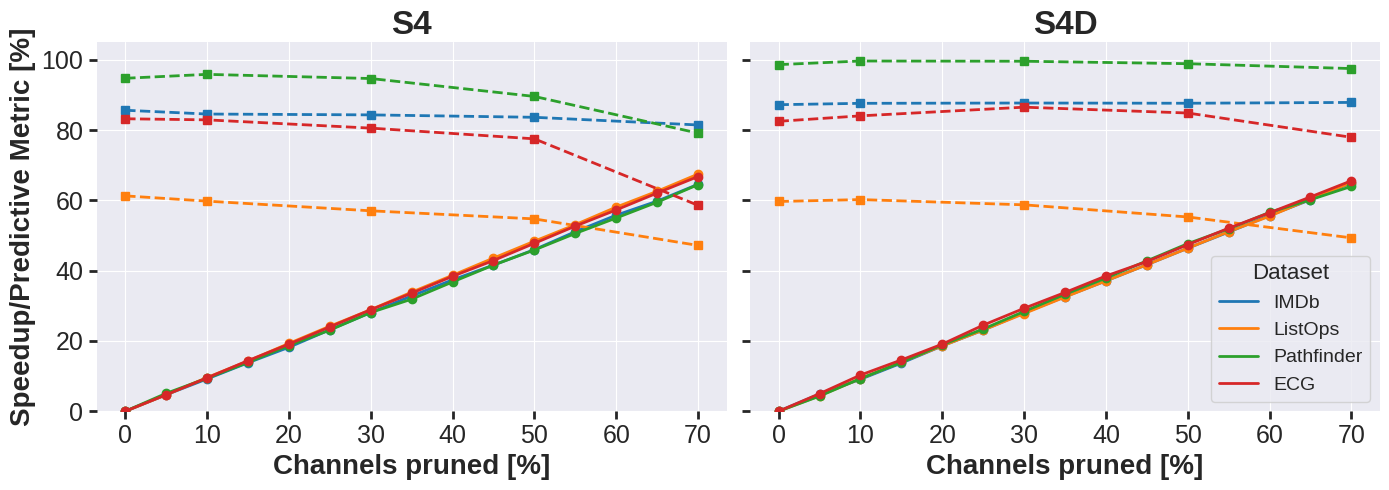

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pruning_perc = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "imdb": [0, 4.7, 9.2, 13.8, 18.2, 23.2, 28.1, 32.8, 37.4, 41.6, 46.0, 51.1, 55.8, 59.8, 64.6],
        "listops": [0, 4.7, 9.6, 14.3, 19.3, 24.2, 28.9, 33.9, 38.7, 43.6, 48.4, 53.1, 58.1, 62.6, 67.5],
        "pathfinder": [0, 5.1, 9.4, 13.9, 18.7, 23.1, 28.1, 31.9, 36.8, 41.6, 45.9, 50.6, 55.0, 59.5, 64.5],
        "ecg": [0, 4.7, 9.5, 14.4, 19.1, 24.0, 28.9, 33.6, 38.4, 42.9, 47.8, 52.7, 57.3, 62.1, 66.8]
    },
    "S4D": {
        "imdb": [0, 4.9, 9.1, 13.7, 18.6, 23.1, 28.0, 32.6, 37.1, 41.7, 46.4, 51.0, 55.7, 60.2, 65.0],
        "listops": [0, 4.4, 9.3, 14.0, 18.6, 23.1, 27.8, 32.5, 37.1, 41.7, 46.4, 51.1, 55.5, 60.4, 65.1],
        "pathfinder": [0, 4.3, 9.3, 13.9, 18.9, 23.4, 28.4, 33.3, 37.9, 42.8, 47.7, 51.9, 56.6, 60.2, 64.0],
        "ecg": [0, 5.0, 10.3, 14.6, 19.1, 24.5, 29.3, 33.8, 38.5, 42.6, 47.4, 52.1, 56.5, 61.0, 65.6]
    },
} 

acc_values = {
    "S4": {
        "imdb": [85.668, 84.592, 84.352, 83.664, 81.484],
        "listops": [61.300, 59.800, 57.050, 54.750, 47.200],
        "pathfinder": [94.770, 95.885, 94.700, 89.604, 79.159],
        "ecg": [83.247, 82.933, 80.585, 77.534, 58.616]
    },
    "S4D": {
        "imdb": [87.252, 87.640, 87.728, 87.664, 87.896],
        "listops": [59.700, 60.250, 58.750, 55.300, 49.350],
        "pathfinder": [98.655, 99.685, 99.620, 98.920, 97.535],
        "ecg": [82.526, 84.074, 86.543, 84.883, 77.974]
    }
}

pruning_acc = [0, 10, 30, 50, 70]   # punti dove hai accuracy

plt.style.use('seaborn-v0_8-darkgrid')

# colori fissi per dataset
dataset_colors = {
    "imdb": "tab:blue",
    "listops": "tab:orange",
    "pathfinder": "tab:green",
    "ecg": "tab:red"
}

fig, axes = plt.subplots(1, len(results), figsize=(14,5))

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):

    for dataset, speed in model_data.items():

        color = dataset_colors[dataset]

        # SPEEDUP
        ax.plot(
            pruning_perc,
            speed,
            marker='o',
            linewidth=2,
            color=color,
            linestyle='-'
        )

        # ACCURACY
        acc = acc_values[model_name][dataset]

        ax.plot(
            pruning_acc,
            acc,
            marker='s',
            linestyle='--',
            linewidth=2,
            color=color
        )

    ax.set_title(model_name, fontsize=24, fontweight='bold')

    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')

    if model_name == "S4":
        ax.set_ylabel("Speedup/Predictive Metric [%]", fontsize=20, fontweight='bold')
    else:
        ax.tick_params(labelleft=False)

    ax.set_ylim(0,105)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )

    ax.grid(True)

legend_elements = [
    Line2D([0], [0], color=dataset_colors["imdb"], lw=2, label="IMDb"),
    Line2D([0], [0], color=dataset_colors["listops"], lw=2, label="ListOps"),
    Line2D([0], [0], color=dataset_colors["pathfinder"], lw=2, label="Pathfinder"),
    Line2D([0], [0], color=dataset_colors["ecg"], lw=2, label="ECG"),
]

axes[1].legend(
    handles=legend_elements,
    title="Dataset",
    loc='lower right',
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

fig.tight_layout()
plt.show()


## Confronto modello-dataset

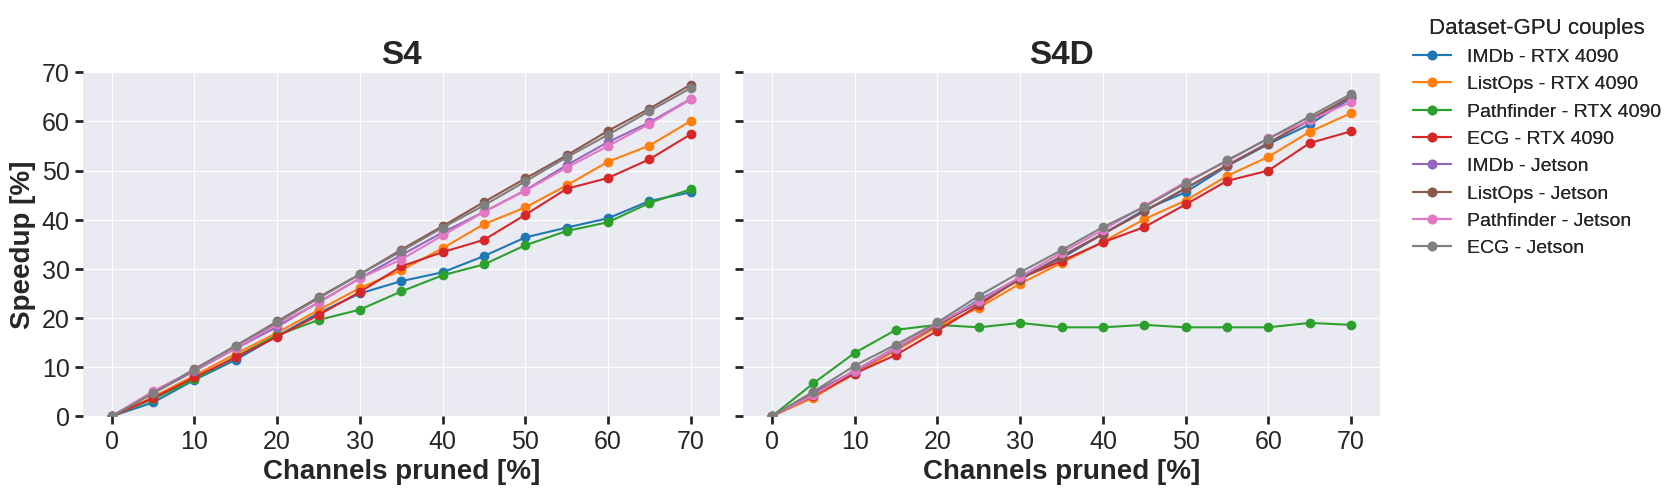

In [63]:
import matplotlib.pyplot as plt

pruning_perc = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

results = {
    "S4": {
        "imdb-parco": [0, 2.8, 7.4, 11.5, 16.3, 21.0, 25.0, 27.5, 29.3, 32.6, 36.4, 38.4, 40.3, 43.8, 45.6],
        "listops-parco": [0, 3.9, 8.3, 12.7, 17.0, 21.6, 26.1, 29.7, 34.2, 39.1, 42.5, 47.0, 51.8, 55.1, 60.1],
        "pathfinder-parco": [0, 3.5, 7.5, 12.1, 16.5, 19.6, 21.7, 25.4, 28.7, 30.9, 34.8, 37.7, 39.5, 43.4, 46.2],
        "ecg-parco": [0, 3.7, 7.9, 12.0, 16.2, 20.6, 25.3, 30.5, 33.4, 35.9, 41.0, 46.3, 48.5, 52.3, 57.4],
        "imdb-jetson": [0, 4.7, 9.2, 13.8, 18.2, 23.2, 28.1, 32.8, 37.4, 41.6, 46.0, 51.1, 55.8, 59.8, 64.6],
        "listops-jetson": [0, 4.7, 9.6, 14.3, 19.3, 24.2, 28.9, 33.9, 38.7, 43.6, 48.4, 53.1, 58.1, 62.6, 67.5],
        "pathfinder-jetson": [0, 5.1, 9.4, 13.9, 18.7, 23.1, 28.1, 31.9, 36.8, 41.6, 45.9, 50.6, 55.0, 59.5, 64.5],
        "ecg-jetson": [0, 4.7, 9.5, 14.4, 19.1, 24.0, 28.9, 33.6, 38.4, 42.9, 47.8, 52.7, 57.3, 62.1, 66.8]
    },
    "S4D": {
        "imdb-parco": [0, 4.6, 9.2, 13.8, 18.5, 23.7, 28.1, 32.2, 37.1, 42.0, 45.6, 50.9, 55.4, 59.4, 64.8],
        "listops-parco": [0, 3.8, 8.7, 13.4, 18.2, 22.1, 27.0, 31.2, 35.5, 40.1, 43.9, 48.9, 52.8, 57.9, 61.7],
        "pathfinder-parco": [0, 6.7, 12.9, 17.6, 18.6, 18.1, 19.0, 18.1, 18.1, 18.6, 18.1, 18.1, 18.1, 19.0, 18.6],
        "ecg-parco": [0, 4.2, 8.7, 12.5, 17.4, 22.6, 28.1, 31.6, 35.4, 38.5, 43.1, 47.9, 50.0, 55.6, 58.0],
        "imdb-jetson": [0, 4.9, 9.1, 13.7, 18.6, 23.1, 28.0, 32.6, 37.1, 41.7, 46.4, 51.0, 55.7, 60.2, 65.0],
        "listops-jetson": [0, 4.4, 9.3, 14.0, 18.6, 23.1, 27.8, 32.5, 37.1, 41.7, 46.4, 51.1, 55.5, 60.4, 65.1],
        "pathfinder-jetson": [0, 4.3, 9.3, 13.9, 18.9, 23.4, 28.4, 33.3, 37.9, 42.8, 47.7, 51.9, 56.6, 60.2, 64.0],
        "ecg-jetson": [0, 5.0, 10.3, 14.6, 19.1, 24.5, 29.3, 33.8, 38.5, 42.6, 47.4, 52.1, 56.5, 61.0, 65.6]
    },
} 

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, len(results), figsize=(14, 5), sharey=True)

if len(results) == 1:
    axes = [axes]

for ax, (model_name, model_data) in zip(axes, results.items()):
    for pattern_name, acc_values in model_data.items():
        if pattern_name == "3":
            color = "black"
        ax.plot(pruning_perc, acc_values, marker='o', label=pattern_name, color=color if pattern_name in ["3"] else None)
    
    ax.set_title(f"{model_name}" if model_name == "S4" else f"{model_name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Channels pruned [%]", fontsize=20, fontweight='bold')
    if model_name == "S4":
        ax.set_ylabel("Speedup [%]", fontsize=20, fontweight='bold')
    ax.set_ylim(0, 70)
    ax.grid(True)
    ax.set_yticks(range(0, 71, 10))
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=18,
        length=6,
        width=2
    )
    fig.legend(["IMDb - RTX 4090", "ListOps - RTX 4090", "Pathfinder - RTX 4090", "ECG - RTX 4090", "IMDb - Jetson", "ListOps - Jetson", "Pathfinder - Jetson", "ECG - Jetson"], title="Dataset-GPU couples", loc='upper left', bbox_to_anchor=(1, 1), fontsize=14, title_fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
